In [1]:
# Starting point for the Data Quality notebook.
# We pick up from events_silver.parquet, which already has:
# - Explicit column types (product_id/user_id as INTEGER, price as FLOAT)
# - Combined October + November data
# - The category_code fix applied (missing codes filled with "unknown_<category_id>")
# This confirms we're picking up in the right place before continuing.

import duckdb

result = duckdb.sql("""
    SELECT COUNT(*) AS total_rows
    FROM '../data/events_silver.parquet'
""")

result.show()

┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│  109950743 │
└────────────┘



In [2]:
# Check whether duplicate rows are concentrated in specific event_types,
# or spread evenly across view/cart/purchase.
# We reuse the same duplicate-detection logic as before, but now group
# the results by event_type to see where duplication is actually happening.

result = duckdb.sql("""
    SELECT
        event_type,
        COUNT(*) AS duplicate_rows
    FROM (
        SELECT *, COUNT(*) AS dup_count
        FROM '../data/events_silver.parquet'
        GROUP BY ALL
    )
    WHERE dup_count > 1
    GROUP BY event_type
    ORDER BY duplicate_rows DESC
""")

result.show()

┌────────────┬────────────────┐
│ event_type │ duplicate_rows │
│  varchar   │     int64      │
├────────────┼────────────────┤
│ cart       │          71961 │
│ view       │           3606 │
│ purchase   │             85 │
└────────────┴────────────────┘



In [9]:
# Remove exact duplicate rows, keeping only the first occurrence of each.
# ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...) assigns a sequential number
# to each row WITHIN each group of identical rows (1, 2, 3...).
# We then keep only rn = 1 - the "first" copy of each duplicate group.

duckdb.sql("""
    COPY (
        SELECT * EXCLUDE (rn)
        FROM (
            SELECT *,
                ROW_NUMBER() OVER (
                    PARTITION BY event_time, event_type, product_id, category_id, 
                                 category_code, brand, price, user_id, user_session, source_file
                    ORDER BY event_time
                ) AS rn
            FROM '../data/events_silver.parquet'
        )
        WHERE rn = 1
    )
    TO '../data/events_silver_dedup.parquet'
    (FORMAT PARQUET)
""")

print("Done removing exact duplicates")

Done removing exact duplicates


In [4]:
import os

data_folder = "../data"
for f in os.listdir(data_folder):
    path = os.path.join(data_folder, f)
    size_gb = os.path.getsize(path) / (1024**3)
    print(f"{f}: {size_gb:.2f} GB")

2019-Nov.csv: 8.39 GB
2019-Nov.parquet: 2.29 GB
2019-Nov_typed.parquet: 2.25 GB
2019-Oct.csv: 5.28 GB
2019-Oct.parquet: 1.42 GB
2019-Oct_typed.parquet: 1.40 GB
events_bronze.parquet: 3.66 GB
events_silver.parquet: 3.71 GB
events_silver_dedup.parquet: 0.00 GB


In [7]:
import os

path = "../data/events_silver_dedup.parquet"
if os.path.exists(path):
    print(f"File exists, size: {os.path.getsize(path) / (1024**3):.2f} GB")
else:
    print("File does not exist")

File exists, size: 0.00 GB


In [8]:
if os.path.exists(path):
    os.remove(path)
    print("Deleted leftover file")

Deleted leftover file


In [10]:
# Verify: new row count should be exactly the old count minus the duplicates we found
# 109,950,743 - 75,652 = 109,875,091

result = duckdb.sql("""
    SELECT COUNT(*) AS deduped_row_count
    FROM '../data/events_silver_dedup.parquet'
""")

result.show()

┌───────────────────┐
│ deduped_row_count │
│       int64       │
├───────────────────┤
│         109820004 │
└───────────────────┘



In [11]:
result = duckdb.sql("""
    SELECT COUNT(*) AS total_rows_involved_in_duplicates
    FROM (
        SELECT *, COUNT(*) AS dup_count
        FROM '../data/events_silver.parquet'
        GROUP BY ALL
    )
    WHERE dup_count > 1
""")
result.show()

┌───────────────────────────────────┐
│ total_rows_involved_in_duplicates │
│               int64               │
├───────────────────────────────────┤
│                             75652 │
└───────────────────────────────────┘



In [12]:
result = duckdb.sql("""
    SELECT COUNT(*) AS remaining_duplicates
    FROM (
        SELECT *, COUNT(*) AS dup_count
        FROM '../data/events_silver_dedup.parquet'
        GROUP BY ALL
    )
    WHERE dup_count > 1
""")
result.show()

┌──────────────────────┐
│ remaining_duplicates │
│        int64         │
├──────────────────────┤
│                    0 │
└──────────────────────┘



In [13]:
# Count the actual number of DISTINCT duplicate groups (not rows).
# If group sizes vary (e.g. some appear 78 times, others just twice),
# rows_removed = (rows in each group - 1), summed across all groups.
# This tells us the true expected removal count.

result = duckdb.sql("""
    SELECT COUNT(*) AS num_duplicate_groups
    FROM (
        SELECT *, COUNT(*) AS dup_count
        FROM '../data/events_silver.parquet'
        GROUP BY ALL
        HAVING COUNT(*) > 1
    )
""")
result.show()

┌──────────────────────┐
│ num_duplicate_groups │
│        int64         │
├──────────────────────┤
│                75652 │
└──────────────────────┘



In [14]:
# Get the TRUE total: sum up how many rows exist across all duplicate groups,
# not just the number of groups. This tells us the real row count
# before dedup, restricted to rows that had at least one duplicate.

result = duckdb.sql("""
    SELECT
        COUNT(*) AS num_duplicate_groups,
        SUM(dup_count) AS total_rows_in_those_groups,
        SUM(dup_count) - COUNT(*) AS expected_rows_removed
    FROM (
        SELECT *, COUNT(*) AS dup_count
        FROM '../data/events_silver.parquet'
        GROUP BY ALL
        HAVING COUNT(*) > 1
    )
""")
result.show()

┌──────────────────────┬────────────────────────────┬───────────────────────┐
│ num_duplicate_groups │ total_rows_in_those_groups │ expected_rows_removed │
│        int64         │           int128           │        int128         │
├──────────────────────┼────────────────────────────┼───────────────────────┤
│                75652 │                     206391 │                130739 │
└──────────────────────┴────────────────────────────┴───────────────────────┘



In [15]:
import os

data_folder = "../data"
files = os.listdir(data_folder)
files_with_size = [(f, os.path.getsize(os.path.join(data_folder, f)) / (1024**3)) for f in files]
files_with_size.sort(key=lambda x: -x[1])

for f, size_gb in files_with_size:
    print(f"{f}: {size_gb:.2f} GB")

total = sum(s for _, s in files_with_size)
print(f"\nTotal: {total:.2f} GB")

2019-Nov.csv: 8.39 GB
events_silver_dedup.parquet: 5.73 GB
2019-Oct.csv: 5.28 GB
events_silver.parquet: 3.71 GB
events_bronze.parquet: 3.66 GB
2019-Nov.parquet: 2.29 GB
2019-Nov_typed.parquet: 2.25 GB
2019-Oct.parquet: 1.42 GB
2019-Oct_typed.parquet: 1.40 GB

Total: 34.13 GB


In [16]:
import os

files_to_delete = [
    "events_silver.parquet",
    "events_bronze.parquet",
    "2019-Nov.parquet",
    "2019-Nov_typed.parquet",
    "2019-Oct.parquet",
    "2019-Oct_typed.parquet",
]

data_folder = "../data"
total_freed = 0

for f in files_to_delete:
    path = os.path.join(data_folder, f)
    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024**3)
        os.remove(path)
        total_freed += size_gb
        print(f"Deleted {f} ({size_gb:.2f} GB)")
    else:
        print(f"{f} not found, skipping")

print(f"\nTotal freed: {total_freed:.2f} GB")

Deleted events_silver.parquet (3.71 GB)
Deleted events_bronze.parquet (3.66 GB)
Deleted 2019-Nov.parquet (2.29 GB)
Deleted 2019-Nov_typed.parquet (2.25 GB)
Deleted 2019-Oct.parquet (1.42 GB)
Deleted 2019-Oct_typed.parquet (1.40 GB)

Total freed: 14.73 GB


In [17]:
import os
print(os.path.exists("../data/events_silver_dedup.parquet"))

True


In [18]:
# Look at the 20 highest-priced events and their category/brand context.
# If these are all legitimate high-value categories (electronics, appliances),
# that supports the prices being real. If we see something like a $2,500
# phone case, that's a red flag worth investigating further.

result = duckdb.sql("""
    SELECT
        price,
        category_code,
        brand,
        event_type,
        product_id
    FROM '../data/events_silver_dedup.parquet'
    ORDER BY price DESC
    LIMIT 20
""")

result.show()

┌─────────┬─────────────────────────────┬──────────┬────────────┬────────────┐
│  price  │        category_code        │  brand   │ event_type │ product_id │
│  float  │           varchar           │ varchar  │  varchar   │   int32    │
├─────────┼─────────────────────────────┼──────────┼────────────┼────────────┤
│ 2574.07 │ electronics.clocks          │ rado     │ view       │   21407287 │
│ 2574.07 │ electronics.clocks          │ rado     │ view       │   21407288 │
│ 2574.07 │ electronics.clocks          │ NULL     │ view       │   21408165 │
│ 2574.07 │ electronics.clocks          │ NULL     │ view       │   21408165 │
│ 2574.07 │ electronics.clocks          │ NULL     │ view       │   21408165 │
│ 2574.07 │ electronics.clocks          │ NULL     │ view       │   21408154 │
│ 2574.07 │ electronics.clocks          │ rado     │ view       │   21407288 │
│ 2574.07 │ electronics.clocks          │ NULL     │ view       │   21408165 │
│ 2574.07 │ unknown_2179887855134835524 │ NULL     │

In [19]:
# Look at the lowest NON-ZERO prices to check for suspiciously cheap entries.
# We exclude price = 0 since we already investigated those separately.

result = duckdb.sql("""
    SELECT
        price,
        category_code,
        brand,
        event_type,
        product_id
    FROM '../data/events_silver_dedup.parquet'
    WHERE price > 0
    ORDER BY price ASC
    LIMIT 20
""")

result.show()

┌───────┬─────────────────────────────┬────────────┬────────────┬────────────┐
│ price │        category_code        │   brand    │ event_type │ product_id │
│ float │           varchar           │  varchar   │  varchar   │   int32    │
├───────┼─────────────────────────────┼────────────┼────────────┼────────────┤
│  0.77 │ unknown_2053013558836331105 │ farmstay   │ cart       │  100006594 │
│  0.77 │ unknown_2053013558836331105 │ ekel       │ view       │  100012885 │
│  0.77 │ unknown_2053013558836331105 │ ekel       │ view       │  100012885 │
│  0.77 │ unknown_2141478391348462154 │ NULL       │ view       │   39100010 │
│  0.77 │ unknown_2053013558836331105 │ ekel       │ cart       │  100012918 │
│  0.77 │ unknown_2141478391348462154 │ NULL       │ view       │   39100010 │
│  0.77 │ unknown_2053013558005858861 │ tramontina │ view       │   31600676 │
│  0.77 │ unknown_2141478391348462154 │ NULL       │ view       │   39100012 │
│  0.77 │ unknown_2053013558005858861 │ tramontina │

In [20]:
# Check how many DISTINCT prices exist vs how many rows have a price.
# If prices were freely set per-product, we'd expect a huge variety.
# If many products share exact identical prices, that supports the
# fixed-exchange-rate-conversion theory.

result = duckdb.sql("""
    SELECT
        COUNT(*) AS total_priced_rows,
        COUNT(DISTINCT price) AS distinct_price_values,
        COUNT(DISTINCT product_id) AS distinct_products
    FROM '../data/events_silver_dedup.parquet'
    WHERE price > 0
""")

result.show()

┌───────────────────┬───────────────────────┬───────────────────┐
│ total_priced_rows │ distinct_price_values │ distinct_products │
│       int64       │         int64         │       int64       │
├───────────────────┼───────────────────────┼───────────────────┤
│         109563347 │                 82965 │            205415 │
└───────────────────┴───────────────────────┴───────────────────┘



In [21]:
# Check if matplotlib is available; install it if not
import subprocess
import sys

try:
    import matplotlib
    print(f"matplotlib already installed: {matplotlib.__version__}")
except ImportError:
    print("Not installed - run this in your terminal: pip install matplotlib")

Not installed - run this in your terminal: pip install matplotlib


In [22]:
# Get daily event counts, broken down by event_type, across the full date range.
# CAST(event_time AS DATE) truncates the timestamp down to just the date part,
# dropping the time-of-day - so all events on the same day group together.

daily_counts = duckdb.sql("""
    SELECT
        CAST(event_time AS DATE) AS event_date,
        event_type,
        COUNT(*) AS event_count
    FROM '../data/events_silver_dedup.parquet'
    GROUP BY event_date, event_type
    ORDER BY event_date
""").df()

daily_counts.head(10)

,event_date,event_type,event_count
0,2019-10-01,view,1208217
1,2019-10-01,purchase,19305
2,2019-10-01,cart,16193
3,2019-10-02,view,1154513
4,2019-10-02,purchase,19469
5,2019-10-02,cart,16871
6,2019-10-03,purchase,19255
7,2019-10-03,cart,18702
8,2019-10-03,view,1088667
9,2019-10-04,view,1346243


In [23]:
import matplotlib.pyplot as plt

# Reshape the data: currently one row per (date, event_type) combo.
# pivot() reshapes it so each event_type becomes its own column,
# with event_date as the row index - this is the shape matplotlib needs
# to draw one line per event_type.

pivoted = daily_counts.pivot(index="event_date", columns="event_type", values="event_count")

pivoted.head()

event_type,cart,purchase,view
event_date,,,
2019-10-01,16193.0,19305.0,1208217.0
2019-10-02,16871.0,19469.0,1154513.0
2019-10-03,18702.0,19255.0,1088667.0
2019-10-04,42657.0,27039.0,1346243.0
2019-10-05,34564.0,23492.0,1271278.0


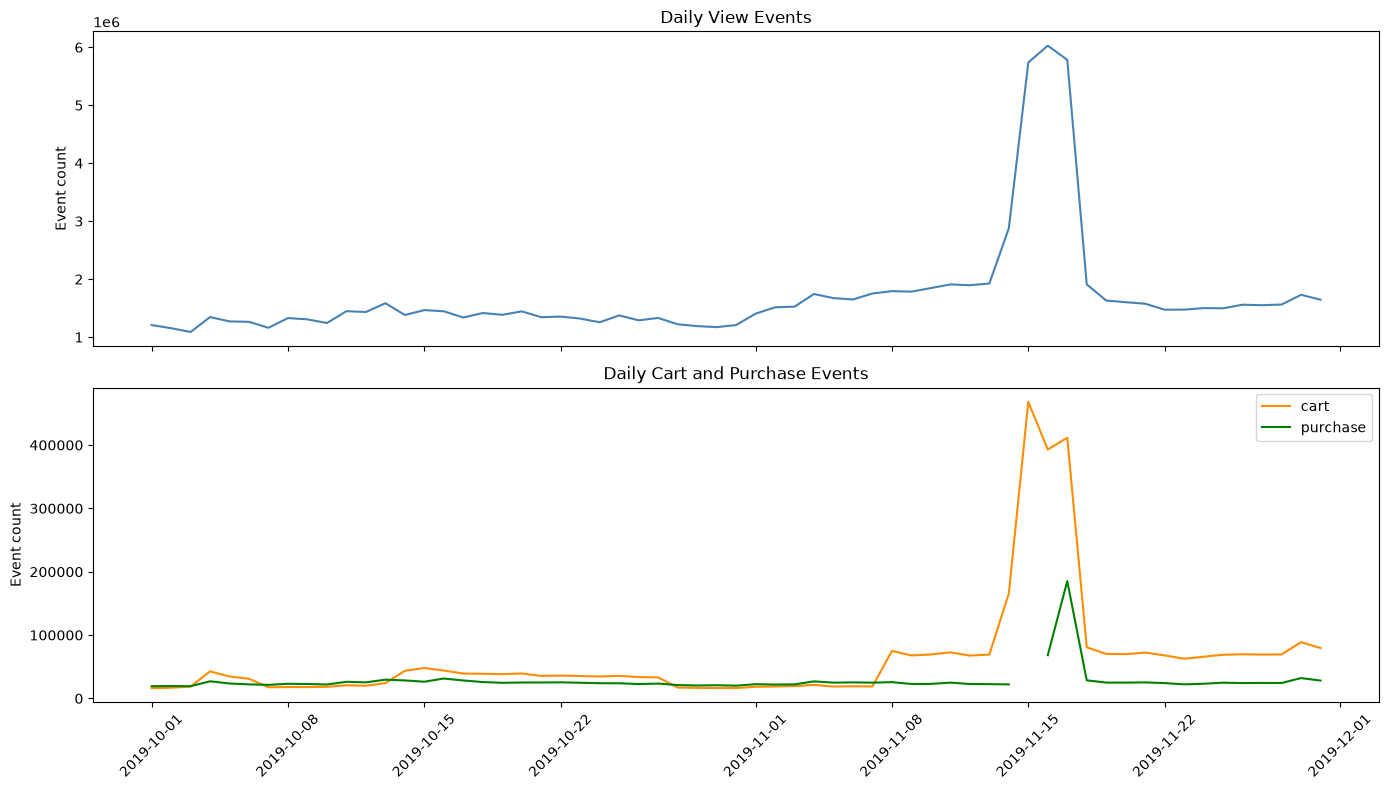

In [24]:
# Plot each event type as its own line over time.
# We use two separate subplots since 'view' is on a MUCH larger scale
# than 'cart' and 'purchase' - plotting them together on one axis would
# make cart/purchase look like flat lines near zero.

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(pivoted.index, pivoted["view"], color="steelblue")
axes[0].set_title("Daily View Events")
axes[0].set_ylabel("Event count")

axes[1].plot(pivoted.index, pivoted["cart"], label="cart", color="darkorange")
axes[1].plot(pivoted.index, pivoted["purchase"], label="purchase", color="green")
axes[1].set_title("Daily Cart and Purchase Events")
axes[1].set_ylabel("Event count")
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
import os

# Create the docs folder if it doesn't already exist
os.makedirs("../docs", exist_ok=True)

print(os.path.exists("../docs"))

True


In [27]:
fig.savefig("../docs/black_friday_spike.png", dpi=150, bbox_inches="tight")
print("Chart saved")

Chart saved


In [29]:
# Check for gaps in daily coverage: are there any dates in the Oct-Nov range
# that are missing entirely, or that have suspiciously low total event counts
# compared to their neighbors (which could indicate a tracking outage)?
import pandas as pd

result = duckdb.sql("""
    SELECT
        CAST(event_time AS DATE) AS event_date,
        COUNT(*) AS total_events
    FROM '../data/events_silver_dedup.parquet'
    GROUP BY event_date
    ORDER BY event_date
""").df()

# Check for any gaps in the date sequence itself
full_date_range = pd.date_range(start=result["event_date"].min(), end=result["event_date"].max())
actual_dates = pd.to_datetime(result["event_date"])
missing_dates = full_date_range.difference(actual_dates)

print(f"Date range: {result['event_date'].min()} to {result['event_date'].max()}")
print(f"Total days covered: {len(result)}")
print(f"Missing dates: {list(missing_dates)}")
print()
print("Lowest 5 days by total event count:")
print(result.nsmallest(5, "total_events"))

Date range: 2019-10-01 00:00:00 to 2019-11-30 00:00:00
Total days covered: 61
Missing dates: []

Lowest 5 days by total event count:
   event_date  total_events
2  2019-10-03       1126624
1  2019-10-02       1190853
6  2019-10-07       1199974
29 2019-10-30       1209557
28 2019-10-29       1227001


In [30]:
# Check how many rows have a missing user_session value
result = duckdb.sql("""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) AS missing_session
    FROM '../data/events_silver_dedup.parquet'
""")

result.show()

┌────────────┬─────────────────┐
│ total_rows │ missing_session │
│   int64    │     int128      │
├────────────┼─────────────────┤
│  109820004 │              12 │
└────────────┴─────────────────┘



In [31]:
# For each user_session, count how many DISTINCT user_ids are associated with it.
# If session IDs are working correctly, this should always be 1.
# Anything more than 1 means the same session ID was somehow shared
# across different people - a red flag.

result = duckdb.sql("""
    SELECT
        user_session,
        COUNT(DISTINCT user_id) AS distinct_users
    FROM '../data/events_silver_dedup.parquet'
    WHERE user_session IS NOT NULL
    GROUP BY user_session
    HAVING COUNT(DISTINCT user_id) > 1
""")

result.show()

┌──────────────────────────────────────┬────────────────┐
│             user_session             │ distinct_users │
│               varchar                │     int64      │
├──────────────────────────────────────┼────────────────┤
│ e3da7601-7606-47b8-aa52-e1c92b9c3f60 │              2 │
│ 0ca83caf-c266-4af5-8b7b-7272f6613747 │              2 │
│ 478a43d7-1ac4-43d2-8c29-66d906912635 │              2 │
│ 38862eab-835b-40f7-b0de-c73572e0ffa6 │              2 │
│ 50e5058a-497b-4318-a9ca-4fc85e81e8e7 │              2 │
│ d93094e5-cc41-455b-a19d-d39d3c5f11e2 │              2 │
│ 73c55635-1b10-4f58-8df8-af0933629dbc │              2 │
│ 3f8b29f2-0466-4098-8162-98787d32e223 │              2 │
│ 146625a5-e3b9-4b77-8159-366e0d7331a1 │              2 │
│ 9127f35b-1feb-404a-aa00-907cb37867d2 │              2 │
│                  ·                   │              · │
│                  ·                   │              · │
│                  ·                   │              · │
│ dafbe6fe-4e7

In [32]:
# How many total distinct sessions exist, to put the 939 problematic ones in context
result = duckdb.sql("""
    SELECT COUNT(DISTINCT user_session) AS total_sessions
    FROM '../data/events_silver_dedup.parquet'
    WHERE user_session IS NOT NULL
""")

result.show()

┌────────────────┐
│ total_sessions │
│     int64      │
├────────────────┤
│       23016650 │
└────────────────┘



In [33]:
# Look at all rows for one specific shared session, in full detail,
# to understand what's actually happening - are these genuinely
# different people, or could this be some kind of quirk (e.g. 
# a shared/family device, or a session ID collision)?

result = duckdb.sql("""
    SELECT
        user_id,
        event_time,
        event_type,
        product_id,
        user_session
    FROM '../data/events_silver_dedup.parquet'
    WHERE user_session = 'e3da7601-7606-47b8-aa52-e1c92b9c3f60'
    ORDER BY event_time
""")

result.show()

┌───────────┬─────────────────────┬────────────┬────────────┬──────────────────────────────────────┐
│  user_id  │     event_time      │ event_type │ product_id │             user_session             │
│   int32   │      timestamp      │  varchar   │   int32    │               varchar                │
├───────────┼─────────────────────┼────────────┼────────────┼──────────────────────────────────────┤
│ 576718698 │ 2019-11-25 19:44:30 │ view       │    1004870 │ e3da7601-7606-47b8-aa52-e1c92b9c3f60 │
│ 576718698 │ 2019-11-25 19:44:58 │ cart       │    1004870 │ e3da7601-7606-47b8-aa52-e1c92b9c3f60 │
│ 576718698 │ 2019-11-25 19:45:01 │ cart       │    1004870 │ e3da7601-7606-47b8-aa52-e1c92b9c3f60 │
│ 576718665 │ 2019-11-25 19:45:29 │ cart       │    1004870 │ e3da7601-7606-47b8-aa52-e1c92b9c3f60 │
│ 576718665 │ 2019-11-25 19:45:35 │ cart       │    1004870 │ e3da7601-7606-47b8-aa52-e1c92b9c3f60 │
│ 576718665 │ 2019-11-25 19:45:37 │ cart       │    1004870 │ e3da7601-7606-47b8-aa52-e1c92